In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import sys
sys.path.append('/modules/rhel8/user-apps/fou-modules/fou-hi/toolbox/dev')
import toolbox

/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def latlon2xy(lat,lon,lat_arr,lon_arr,mask=None,maxoff=None,roundvals=True):
    import numpy as np
    from toolbox.utils.BFS import BFS
    a = abs( lat_arr-lat ) + abs( lon_arr-lon )
    ypos, xpos = np.unravel_index(a.argmin(), a.shape)
    if roundvals:
        xpos = int(np.round(xpos))
        ypos = int(np.round(ypos))
    if mask is not None:
        # NOTE: Mask should be 0 over land!!
        ypos_off, xpos_off = BFS(ypos, xpos, mask)
        if maxoff:
            if (np.sqrt((np.abs(xpos-xpos_off)**2)+(np.abs(ypos-ypos_off)**2)) > maxoff):
                print('offset too big')
                return None
            else:
                return xpos_off, ypos_off
        else:
            return xpos_off, ypos_off
    return xpos, ypos


In [3]:
# Define stuff:
# Input observations:
idir_obs          = '/lustre/storeB/users/nilsmk/stormrisk'
# Output data file:
ofile_nc          = os.path.join(idir_obs, 'anemoi_manuscript_obs_and_models_2010-2018_v2_5dec2025.nc')
# Output figures directory:
odir_figs         = '/lustre/storeB/users/nilsmk/anemoi-datasets/figs'
# Read observation dataset:
ifile_tseries_obs = os.path.join(idir_obs, 'aggregated_water_level_observations_with_pytide_prediction_dataset_extended_nor_stations_with_4_nora-surge_exps.nc')
if not os.path.exists(ofile_nc):
    ds_obs            = xr.open_dataset(ifile_tseries_obs)
    # Limit dataset to relevant time period:
    # ds_obs            = ds_obs.sel(time=slice('1980-01-01', '2023-01-01'))
    ds_obs            = ds_obs.sel(time=slice('2010-01-01', '2019-01-01'))
    # Select only hourly data:
    ds_obs            = ds_obs.sel(time=ds_obs['time'].dt.minute == 0)
    # Only select the following variables:
    ds_obs            = ds_obs[['stationid', 'latitude', 'longitude', 'observation', 'pytide_prediction', 'q_flag', 'nora3c']]
    # Remove some stations with known bad data:
    # Add stations to remove-list manually:
    remove_manual = ['DK_4203', 'DK_5103', 'DK_5104', 'NL_Aukfield platform', 'NL_F3 platform', 'NL_Maasmond stroommeetpaal', 'NL_Noordwijk meetpost', 'NL_Oosterschelde 11', ]
    for stationid in remove_manual:
        ds_obs = ds_obs.where(ds_obs['stationid'] != stationid, drop=True)
    # Now, if output file does not exist, create it:
# if not os.path.exists(ofile_nc):
    # Convert to dataframe:
    print('Converting observation dataset to dataframe and saving to netCDF file...')
    df_obs            = ds_obs.to_dataframe()

In [4]:
if not os.path.exists(ofile_nc):
    print('Calculating observation_surge and renaming nora3c to nora_surge...')
    # Create new column for observation_surge:
    df_obs['observation_surge'] = df_obs['observation'] - df_obs['pytide_prediction']
    # Rename nora3c to nora_surge:
    df_obs = df_obs.rename(columns={'nora3c': 'nora_surge'})

- First, read the nora3 corrected and put into new column
- Read in the anemoi runs, give good names
- Create a new column in the df with the anemoi run name
- Loop over the stations (or time?) and select the station data and put it into the correct index of the df. __Convert m to cm__
- Redo for more anemoi runs
- Store df to file
- Do statistics and plotting

In [5]:
if not os.path.exists(ofile_nc):
    print('Adding corrected NORA surge data to dataframe...')
    #
    nora_surge_corr = '/lustre/storeB/users/nilsmk/stormrisk/nora3_v2_corrected/{}/ocean_his.nc'
    files_corr = sorted(glob.glob(nora_surge_corr.format('201*')))
    #
    # Create a new column in the dataframe for the corrected nora surge:
    df_obs['nora_surge_corrected'] = np.nan
    #
    # Loop over files and read data, and put into the correct station and time in the dataframe. 
    # Ensure that the units are in cm (not m as in the netcdf files).
    # Calculate the x- and y-indices for each station once based on the first file. Ensure that the selected index contains valid data, else search nearby indices for valid data.
    ds_corr = xr.open_dataset(files_corr[0])
    maskr = np.where(np.isnan(ds_corr.zeta[0,:].values), 0, 1)
    # Precompute station grid indices based on the first file and the stations in df_obs
    station_indices = {}
    for sid,station_id in enumerate(ds_obs.stationid.values):
        print(f'Computing indices for station ID: {station_id}, no. {sid+1} of {len(ds_obs.stationid.values)}')
        lat_station = ds_obs.latitude.sel(station=np.where(ds_obs.stationid==station_id)[0][0]).values
        lon_station = ds_obs.longitude.sel(station=np.where(ds_obs.stationid==station_id)[0][0]).values
        x_index, y_index = latlon2xy(lat_station, lon_station, ds_corr['lat_rho'].values, ds_corr['lon_rho'].values, mask=maskr, roundvals=True)
        station_indices[station_id] = (sid, y_index, x_index)
        print(f'-->Station ID {station_id} assigned to grid indices (y: {y_index}, x: {x_index}). Original lat: {lat_station}, lon: {lon_station}, Grid lat: {ds_corr["lat_rho"][y_index, x_index].values}, lon: {ds_corr["lon_rho"][y_index, x_index].values}')
    ds_corr.close()

In [6]:
if os.path.exists(ofile_nc):
    print(f'Output file {ofile_nc} already exists. Will read data into dataframe from this file.')
    ds_obs = xr.open_dataset(ofile_nc)
    df_obs = ds_obs.to_dataframe()
    ds_obs.close()
else:
    for i, file in enumerate(files_corr):
        print(f'Reading file {i+1} of {len(files_corr)}: {file}')
        ds_corr = xr.open_dataset(file)
        zeta_data_all = ds_corr['zeta'].values * 100.0  # Convert from m to cm
        time_data = ds_corr['ocean_time'].values

        # Loop over stations and extract data
        for station_id, (sid, y_index, x_index) in list(station_indices.items()):
            # print(f'Processing station {sid+1} of {len(station_indices)}')
            
            # Extract data for specific station
            zeta_data = zeta_data_all[:, y_index, x_index]
            
            # Create a temporary dataframe
            df_temp = pd.DataFrame({
                'time': pd.to_datetime(time_data), 
                'nora_surge_corrected': zeta_data
            })
            df_temp.set_index('time', inplace=True)
            
            # --- THE FIX ---
            # 1. Identify rows in df_obs that match the current Station
            # 2. AND match the Time points present in the current file
            mask = (df_obs.index.get_level_values('station') == sid) & \
                (df_obs.index.get_level_values('time').isin(df_temp.index))
            
            # Only update the rows where the mask is True
            # We use .values on the right side to ignore index alignment issues during assignment
            df_obs.loc[mask, 'nora_surge_corrected'] = df_temp['nora_surge_corrected'].values
            
        del zeta_data_all
        ds_corr.close()
    # Save df_obs to a new netcdf file
    df_obs.to_xarray().to_netcdf(ofile_nc)

Output file /lustre/storeB/users/nilsmk/stormrisk/anemoi_manuscript_obs_and_models_2010-2018_v2_5dec2025.nc already exists. Will read data into dataframe from this file.


/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/xarray/backends/plugins.py:64: RuntimeWarning: Engine 'gini' loading failed:
cannot import name 'deprecated' from 'typing_extensions' (/home/nilsmk/.conda/envs/nils_production-10-2022_rhel8/lib/python3.9/site-packages/typing_extensions.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


In [7]:
# # Rename all columns that start with "train5yr" to "train4yr"
# df_obs.columns = [col.replace('train5yr', 'train4yr') if col.startswith('train5yr') else col for col in df_obs.columns]
# # Store dataframe to netcdf file:
# df_obs.to_xarray().to_netcdf(ofile_nc)

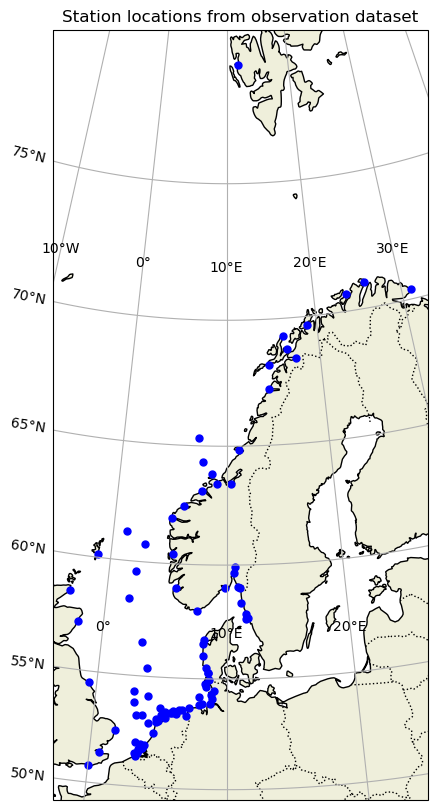

In [8]:
# Plot a map using cartopy with the stations in ofile_nc. Latitudes and longitudes are in df_obs.
# Add lat/lon gridlines
# Use stereographic projection centered over Norway.
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10,10))
# ax = plt.axes(projection=ccrs.Stereographic(central_longitude=10, central_latitude=65))
# Try with LambertConformal:
ax = plt.axes(projection=ccrs.LambertConformal(central_longitude=10, central_latitude=65))
# ax.set_extent([-20, 35, 35, 85], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
# Plot station locations
for sid in df_obs.index.get_level_values('station').unique():
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    lat_station = df_obs.xs(sid, level='station').latitude.values[0]
    lon_station = df_obs.xs(sid, level='station').longitude.values[0]
    ax.plot(lon_station, lat_station, marker='o', color='blue', markersize=5, transform=ccrs.PlateCarree())
    # ax.text(lon_station+0.2, lat_station+0.2, station_id, transform=ccrs.PlateCarree(), size=8)
# Add lat/lon gridlines
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
plt.title('Station locations from observation dataset')
plt.show()


In [9]:
# Now add the anemoi experiments:
idir_anemoi = '/lustre/storeB/users/nilsmk/anemoi-datasets/output/{}/inference'
# Exps: (foldername, shortname, nc_filepattern)
exps_anemoi = [
            #    ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_10d_100k', '????-??-??_240h_step100000.nc'), 
            #    ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_10d_100k', '????-??-??_240h_step100000.nc'),
            #    ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_1year_100k', '????-??-??_1year_step100000.nc'), 
            #    ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_1year_100k', '????-??-??_1year_step100000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_10d_25k', '????-??-??_240h_step025000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_1year_25k', '????-??-??_1year_step025000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_10d_50k', '????-??-??_240h_step050000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_1year_50k', '????-??-??_1year_step050000.nc'),
            #    ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_10d_100k', '????-??-??_240h_step100000.nc'),
            #    # ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_1year_100k', '????-??-??_1year_step100000.nc'), # not added yet, not run inference yet.
               # ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_didrik_100k', 'didrik_2010-01-09_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_didrik_100k', 'didrik_2010-01-09_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_elsa_100k', 'elsa_2010-02-05_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_elsa_100k', 'elsa_2010-02-05_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_xaver_100k', 'xaver_2013-12-01_240h_step100000.nc'),
               # ('longrun_10years_newgraph_90s_corrected', 'train16yr_corr_xaver_100k', 'xaver_2013-12-01_240h_step100000.nc'),
               # ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_xaver_100k', 'xaver_2013-12-01_240h_step100000.nc'),
               ('longrun_10years_newgraph_90s_uncorr', 'train16yr_uncorr_2010-2018_100k', 'long_????-??-??_78840h_step100000.nc'),
               ('longrun_5years_newgraph_90s_uncorr', 'train4yr_uncorr_2010-2018_100k', 'long_????-??-??_78840h_step100000.nc'),
               ]
            # Do inference for 10 days for 5yr train based on 100k, and also 25k
            # Do inference for 1 year for all runs
            # Do continous inference from 2010-2018 for all?


# Evaluate the 10days (240h) inference for each exp (only 2013). 
# Also add the 1year inference from longrun_1980-2012 (for years 2013 - 2022)

# Loop over all exps in exps_anemoi and print the directory and exp name together with the number of files found.
for foldername, shortname, nc_filepattern in exps_anemoi:
    idir_exp = idir_anemoi.format(foldername)
    filepattern = os.path.join(idir_exp, nc_filepattern)
    files_exp = sorted(glob.glob(filepattern))
    print(f'Exp: {foldername}, shortname: {shortname}, number of files found: {len(files_exp)}')

Exp: longrun_10years_newgraph_90s_uncorr, shortname: train16yr_uncorr_2010-2018_100k, number of files found: 1
Exp: longrun_5years_newgraph_90s_uncorr, shortname: train4yr_uncorr_2010-2018_100k, number of files found: 1


In [10]:
if False: # add anemoi exps to DF # USE THIS!!
    # Loop over all anemoi exps
    for exp in exps_anemoi:
        foldername, shortname, filepattern = exp
        print(f'Processing Anemoi experiment: {foldername}, shortname: {shortname}')
        idir_exp = idir_anemoi.format(foldername)
        files_exp = sorted(glob.glob(os.path.join(idir_exp, filepattern)))

        for i, file in enumerate(files_exp):
            print(f'Reading file {i+1} of {len(files_exp)}: {file}')
            ds_anemoi = xr.open_dataset(file)

            # Load coordinate data
            _zeta = ds_anemoi.zeta
            _lat = ds_anemoi.latitude
            _lon = ds_anemoi.longitude
            lat = np.reshape(_lat.values, (570, 1014))
            lon = np.reshape(_lon.values, (570, 1014))
            _time = ds_anemoi.time

            # Define chunk size (e.g., 2000 or 3000 as per your previous code)
            CHUNK_SIZE = 3000
            chunks = np.arange(0, _zeta.shape[0], CHUNK_SIZE)

            for ci, chunk in enumerate(chunks):
                c1 = chunk
                # FIX 1: Removed the '-1'. Python slicing excludes the end index,
                # so we want the start of the next chunk to be the end of this slice.
                c2 = _zeta.shape[0] if (chunk == chunks.max()) else chunks[ci+1]

                # Slice time and data
                time_chunk = _time[c1:c2]
                print(f'Chunk {ci+1}/{len(chunks)}: indices {c1}:{c2}, time {time_chunk.values[0]} to {time_chunk.values[-1]}')

                # Extract zeta chunk and reshape
                # Use .values to extract numpy array immediately for speed
                zeta_chunk = np.reshape(_zeta[c1:c2, :].values, (c2-c1, 570, 1014)) * 100.0

                # --- ONE-TIME INITIALIZATION (First File, First Chunk) ---
                if i == 0 and ci == 0:
                    print('Computing station indices for Anemoi data...')
                    # Initialize the column with NaNs
                    df_obs[shortname] = np.nan

                    station_indices_anemoi = {}
                    maskr_anemoi = np.where(np.isnan(zeta_chunk[0, :]), 0, 1) # Use current chunk for mask

                    # Pre-calculate indices for all stations
                    for sid in df_obs.index.get_level_values('station').unique():
                        # Assuming sid is the label in the index
                        lat_station = df_obs.latitude.xs(sid, level='station').values[0]
                        lon_station = df_obs.longitude.xs(sid, level='station').values[0]

                        # Compute grid indices
                        x_index, y_index = latlon2xy(lat_station, lon_station, lat, lon, mask=maskr_anemoi, roundvals=True)

                        # Store mapping: station_label -> (grid_y, grid_x)
                        # We store 'sid' (the index label) to easily look up in df_obs later
                        station_indices_anemoi[sid] = (y_index, x_index)

                # --- PROCESS STATIONS FOR CURRENT CHUNK ---
                # Create a shared time index for this chunk to speed up loop
                # Ensure it matches the precision of df_obs index
                chunk_time_index = pd.to_datetime(time_chunk.values)

                for sid, (y_index, x_index) in station_indices_anemoi.items():
                    # Extract data for this station at this chunk of time
                    # Shape: (Time,)
                    zeta_data = zeta_chunk[:, y_index, x_index]

                    # FIX 2: Direct MultiIndex Assignment
                    # Instead of a boolean mask (which can be slow or ambiguous), 
                    # we construct the exact MultiIndex (Station, Time) we want to write to.

                    # Create the MultiIndex for (Current Station, Current Chunk Times)
                    # This assumes df_obs has levels ['station', 'time']
                    idx_to_update = pd.MultiIndex.from_product([[sid], chunk_time_index], names=['station', 'time'])

                    # Assign values. 
                    # Using .loc with a MultiIndex ensures we update exactly these rows.
                    # We wrap zeta_data in .values to ensure shape-based assignment (ignoring index alignment inside the assignment)

                    # Note: This will only update rows that exist in df_obs. 
                    # If df_obs is missing these times, this line might error or do nothing depending on pandas version.
                    # Since df_obs is your "Observation" frame, we assume it contains the target times.
                    try:
                        df_obs.loc[idx_to_update, shortname] = zeta_data
                    except KeyError:
                        # Fallback: If exact index match fails (e.g. slight time mismatch), use the boolean mask method
                        # This handles cases where df_obs might not have exactly all times in the chunk
                        mask = (df_obs.index.get_level_values('station') == sid) & \
                               (df_obs.index.get_level_values('time').isin(chunk_time_index))
                        df_obs.loc[mask, shortname] = zeta_data

            ds_anemoi.close()

        # Save intermediate to netcdf
        print(f"Saving intermediate result for {shortname}...")
        df_obs.to_xarray().to_netcdf(ofile_nc)

    # Now read again from netcdf to ensure consistency
    ds_out = xr.open_dataset(ofile_nc)
    df_obs = ds_out.to_dataframe()
    ds_out.close()
    print('All done. Final dataset saved to netCDF file.')

In [11]:
df_obs.index.get_level_values('station').unique()

Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
            51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
            68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
            85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97],
           dtype='int64', name='station')

In [12]:
# for i in df_obs.index.get_level_values('station').unique():
#     print(i, df_obs.xs(i, level='station').stationid.values[0])

In [13]:
# Loop over all stations, select the stations where stationid starts with 'NO_', create an array of these sids.
no_station_sids = []
for sid in df_obs.index.get_level_values('station').unique():
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    if station_id.startswith('NO_'):
        no_station_sids.append(sid)
print(no_station_sids)

[62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85]


In [14]:
def plot_scatter(df_obs, exps_anemoi, odir_figs, showfig=False, maxval=None, minval=None, fig_prefix='', debug=False):
    # Create scatter plots for all stations for 2013 comparing observations and model experiments
    # Put all exps for each station in one figure with subplots for each exp. Use the station ID as title. Save figures to odir_figs.
    # Add a diagonal 1:1 line for reference. If no plottable points, skip that station.
    all_rmse = {}
    all_bias = {}
    all_corr = {}
    for sid in df_obs.index.get_level_values('station').unique():
        station_id = df_obs.xs(sid, level='station').stationid.values[0]
        if debug:
            print(f"Creating scatter plot for station ID: {station_id}, no. {sid+1} of {len(df_obs.index.get_level_values('station').unique())}")
        df_station = df_obs.xs(sid, level='station')
        exps_to_plot = ['nora_surge', 'nora_surge_corrected'] + [exp[1] for exp in exps_anemoi]
        # exps_to_plot = ['nora_surge'] + [exp[1] for exp in exps_anemoi]
        n_exps = len(exps_to_plot)
        plottable = False
        for j, exp_name in enumerate(exps_to_plot):
            x = df_station['observation_surge']
            y = df_station[exp_name]
            # Remove NaN and inf values
            mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
            x = x[mask]
            y = y[mask]
            # Remove the mean from both x and y to focus on surge anomalies
            x = x - np.mean(x)
            y = y - np.mean(y)
            if len(x) > 0:
                plottable = True
                if j == 0:
                    fig, axes = plt.subplots(1, n_exps, figsize=(5*n_exps, 5), squeeze=False)
                ax = axes[0, j]
                ax.scatter(x, y, alpha=0.5, s=5)
                if minval is None:
                    minval = min(np.min(x), np.min(y))
                if maxval is None:
                    maxval = max(np.max(x), np.max(y))
                ax.plot([minval, maxval], [minval, maxval], 'r--')
                ax.set_xlabel('Observed Surge (cm)')
                ax.set_ylabel(f'Model Surge ({exp_name}) (cm)')
                ax.set_title(f'Exp: {exp_name}')
                ax.set_xlim([minval, maxval])
                ax.set_ylim([minval, maxval])
                ax.grid(True)
                # Add statistics in the plot: RMSE, Bias, Correlation
                rmse = np.sqrt(np.mean((y - x)**2))
                bias = np.mean(y - x)
                corr = np.corrcoef(x, y)[0, 1]
                all_rmse.setdefault(exp_name, []).append(rmse)
                all_bias.setdefault(exp_name, []).append(bias)
                all_corr.setdefault(exp_name, []).append(corr)
                ax.text(0.05, 0.95, f'RMSE: {rmse:.2f} cm\nCorr: {corr:.2f}', transform=ax.transAxes, 
                        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
            else:
                pass
        if plottable:
            plt.suptitle(f'Scatter plots of Observed vs Modeled Surge for Station ID: {station_id}')
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            ofile_fig = os.path.join(odir_figs, f'{fig_prefix}scatter_observed_vs_modeled_surge_station_{station_id}.png')
            plt.savefig(ofile_fig)
            if showfig:
                plt.show()
            plt.close(fig)
    return all_rmse, all_bias, all_corr

In [15]:
# Loop over all the stations and calculate the standard deviation of the observation_surge for each station. 
# Calculate the RMSE of each model exp compared to observation_surge, and scale the RMSE by the standard deviation of the observation_surge to get a normalized RMSE. 
# Store the results in a dictionary for each exp.
all_rmse_scaled = {}
all_bias_scaled = {}
all_corr_scaled = {}

all_rmse = {}
all_bias = {}
all_corr = {}

exp_list = ['nora_surge'] + [exp[1] for exp in exps_anemoi]

for sid in df_obs.index.get_level_values('station').unique():
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    station_std = np.std(df_obs.xs(sid, level='station')['observation_surge'].dropna())
    if station_std == 0:
        continue
    for shortname in exp_list:
        x = df_obs.xs(sid, level='station')['observation_surge']
        y = df_obs.xs(sid, level='station')[shortname]
        # Remove NaN and inf values
        mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
        x = x[mask]
        y = y[mask]
        # Remove the mean from both x and y to focus on surge anomalies
        x = x - np.mean(x)
        y = y - np.mean(y)
        if len(x) > 0:
            rmse = np.sqrt(np.mean((y - x)**2))
            bias = np.mean(y - x)
            corr = np.corrcoef(x, y)[0, 1]
            all_rmse.setdefault(shortname, []).append(rmse)
            all_bias.setdefault(shortname, []).append(bias)
            all_corr.setdefault(shortname, []).append(corr)
            rmse_scaled = rmse / station_std
            bias_scaled = bias / station_std
            all_rmse_scaled.setdefault(shortname, []).append(rmse_scaled)
            all_bias_scaled.setdefault(shortname, []).append(bias_scaled)
            all_corr_scaled.setdefault(shortname, []).append(corr)
        else:
            print(f'Skipped station with no plottable data: {station_id}, (sid: {sid}) for exp: {shortname}')


Skipped station with no plottable data: NL_Engelsmanplaat noord, (sid: 16) for exp: nora_surge
Skipped station with no plottable data: NL_Engelsmanplaat noord, (sid: 16) for exp: train16yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Engelsmanplaat noord, (sid: 16) for exp: train4yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Haringvlietmond, (sid: 19) for exp: nora_surge
Skipped station with no plottable data: NL_Haringvlietmond, (sid: 19) for exp: train16yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Haringvlietmond, (sid: 19) for exp: train4yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Horsborngat, (sid: 22) for exp: nora_surge
Skipped station with no plottable data: NL_Horsborngat, (sid: 22) for exp: train16yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Horsborngat, (sid: 22) for exp: train4yr_uncorr_2010-2018_100k
Skipped station with no plottable data: NL_Oosterschelde 13, (si

In [19]:
# Do the same as above, but mask the data when the observations are below 10 cm in absolute value.
# threshold = 10.0  # cm
threshold = 30.0  # cm


all_rmse_scaled_thresh = {}
all_bias_scaled_thresh = {}
all_corr_scaled_thresh = {}

all_rmse_thresh = {}
all_bias_thresh = {}
all_corr_thresh = {}

# for sid in df_obs.index.get_level_values('station').unique():
for sid in no_station_sids:
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    station_std = np.std(df_obs.xs(sid, level='station')['observation_surge'].dropna())
    if station_std == 0:
        continue
    for shortname in exp_list:
        x = df_obs.xs(sid, level='station')['observation_surge']
        y = df_obs.xs(sid, level='station')[shortname]
        # Remove NaN and inf values
        mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
        x = x[mask]
        y = y[mask]
        # Remove the mean from both x and y to focus on surge anomalies
        x = x - np.mean(x)
        y = y - np.mean(y)
        # Apply threshold mask
        thresh_mask = np.abs(x) >= threshold
        x = x[thresh_mask]
        y = y[thresh_mask]
        if len(x) > 0:
            rmse = np.sqrt(np.mean((y - x)**2))
            bias = np.mean(y - x)
            corr = np.corrcoef(x, y)[0, 1]
            all_rmse_thresh.setdefault(shortname, []).append(rmse)
            all_bias_thresh.setdefault(shortname, []).append(bias)
            all_corr_thresh.setdefault(shortname, []).append(corr)
            rmse_scaled = rmse / station_std
            bias_scaled = bias / station_std
            all_rmse_scaled_thresh.setdefault(shortname, []).append(rmse_scaled)
            all_bias_scaled_thresh.setdefault(shortname, []).append(bias_scaled)
            all_corr_scaled_thresh.setdefault(shortname, []).append(corr)
        else:
            print(f'Skipped station with no plottable data after thresholding: {station_id}, (sid: {sid}) for exp: {shortname}')

In [17]:
# Print overall statistics scaled by the standard deviation for each exp, excluding nans and infs. Also print the mean RMSE, Bias and Correlation.
for shortname in all_rmse_scaled:
    rmse_scaled_values = np.array(all_rmse_scaled[shortname])
    bias_scaled_values = np.array(all_bias_scaled[shortname])
    corr_scaled_values = np.array(all_corr_scaled[shortname])
    print(f"{shortname}:")
    print(f"  Mean RMSE (scaled): {np.nanmean(rmse_scaled_values):.3f}")
    print(f"  Mean Bias (scaled): {np.nanmean(bias_scaled_values):.3f}")
    print(f"  Mean Correlation: {np.nanmean(corr_scaled_values):.3f}")
    rmse_values = np.array(all_rmse[shortname])
    bias_values = np.array(all_bias[shortname])
    corr_values = np.array(all_corr[shortname])
    print(f"  Mean RMSE: {np.nanmean(rmse_values):.3f} cm")
    print(f"  Mean Bias: {np.nanmean(bias_values):.3f} cm")
    print(f"  Mean Correlation: {np.nanmean(corr_values):.3f}")

nora_surge:
  Mean RMSE (scaled): 0.551
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.854
  Mean RMSE: 12.632 cm
  Mean Bias: -0.000 cm
  Mean Correlation: 0.854
train16yr_uncorr_2010-2018_100k:
  Mean RMSE (scaled): 0.540
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.858
  Mean RMSE: 12.424 cm
  Mean Bias: -0.000 cm
  Mean Correlation: 0.858
train4yr_uncorr_2010-2018_100k:
  Mean RMSE (scaled): 0.578
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.841
  Mean RMSE: 13.111 cm
  Mean Bias: -0.000 cm
  Mean Correlation: 0.841


In [20]:
# Print the statistics with thresholding applied
for shortname in all_rmse_scaled_thresh:
    rmse_scaled_values = np.array(all_rmse_scaled_thresh[shortname])
    bias_scaled_values = np.array(all_bias_scaled_thresh[shortname])
    corr_scaled_values = np.array(all_corr_scaled_thresh[shortname])
    print(f"{shortname} (thresholded {threshold}):")
    print(f"  Mean RMSE (scaled): {np.nanmean(rmse_scaled_values):.3f}")
    print(f"  Mean Bias (scaled): {np.nanmean(bias_scaled_values):.3f}")
    print(f"  Mean Correlation: {np.nanmean(corr_scaled_values):.3f}")
    rmse_values = np.array(all_rmse_thresh[shortname])
    bias_values = np.array(all_bias_thresh[shortname])
    corr_values = np.array(all_corr_thresh[shortname])
    print(f"  Mean RMSE: {np.nanmean(rmse_values):.3f} cm")
    print(f"  Mean Bias: {np.nanmean(bias_values):.3f} cm")
    print(f"  Mean Correlation: {np.nanmean(corr_values):.3f}")

nora_surge (thresholded 30.0):
  Mean RMSE (scaled): 0.650
  Mean Bias (scaled): 0.306
  Mean Correlation: 0.973
  Mean RMSE: 10.314 cm
  Mean Bias: 4.695 cm
  Mean Correlation: 0.973
train16yr_uncorr_2010-2018_100k (thresholded 30.0):
  Mean RMSE (scaled): 0.626
  Mean Bias (scaled): 0.253
  Mean Correlation: 0.973
  Mean RMSE: 9.963 cm
  Mean Bias: 3.900 cm
  Mean Correlation: 0.973
train4yr_uncorr_2010-2018_100k (thresholded 30.0):
  Mean RMSE (scaled): 0.708
  Mean Bias (scaled): 0.348
  Mean Correlation: 0.968
  Mean RMSE: 11.207 cm
  Mean Bias: 5.358 cm
  Mean Correlation: 0.968


In [10]:
# Do the same as above, but only for the Norwegian stations given by no_station_sids
all_rmse_scaled_no = {}
all_bias_scaled_no = {}
all_corr_scaled_no = {}

for sid in no_station_sids:
    station_id = df_obs.xs(sid, level='station').stationid.values[0]
    station_std = np.std(df_obs.xs(sid, level='station')['observation_surge'].dropna())
    if station_std == 0:
        continue
    for shortname in exp_list:
        x = df_obs.xs(sid, level='station')['observation_surge']
        y = df_obs.xs(sid, level='station')[shortname]
        # Remove NaN and inf values
        mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
        x = x[mask]
        y = y[mask]
        # Remove the mean from both x and y to focus on surge anomalies
        x = x - np.mean(x)
        y = y - np.mean(y)
        if len(x) > 0:
            rmse = np.sqrt(np.mean((y - x)**2))
            bias = np.mean(y - x)
            corr = np.corrcoef(x, y)[0, 1]
            rmse_scaled = rmse / station_std
            bias_scaled = bias / station_std
            all_rmse_scaled_no.setdefault(shortname, []).append(rmse_scaled)
            all_bias_scaled_no.setdefault(shortname, []).append(bias_scaled)
            all_corr_scaled_no.setdefault(shortname, []).append(corr)

In [11]:
# Print Norwegian statistics scaled by the standard deviation for each exp, excluding nans and infs
for shortname in all_rmse_scaled_no:
    rmse_scaled_values = np.array(all_rmse_scaled_no[shortname])
    bias_scaled_values = np.array(all_bias_scaled_no[shortname])
    corr_scaled_values = np.array(all_corr_scaled_no[shortname])
    print(f"{shortname} (Norwegian stations):")
    print(f"  Mean RMSE (scaled): {np.nanmean(rmse_scaled_values):.3f}")
    print(f"  Mean Bias (scaled): {np.nanmean(bias_scaled_values):.3f}")
    print(f"  Mean Correlation: {np.nanmean(corr_scaled_values):.3f}")

nora_surge (Norwegian stations):
  Mean RMSE (scaled): 0.530
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.867
train16yr_uncorr_2010-2018_100k (Norwegian stations):
  Mean RMSE (scaled): 0.510
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.876
train4yr_uncorr_2010-2018_100k (Norwegian stations):
  Mean RMSE (scaled): 0.583
  Mean Bias (scaled): -0.000
  Mean Correlation: 0.848


In [8]:
df_obs.columns

Index(['stationid', 'latitude', 'longitude', 'observation',
       'pytide_prediction', 'q_flag', 'nora_surge', 'observation_surge',
       'nora_surge_corrected', 'train16yr_uncorr_10d_100k',
       'train16yr_corr_10d_100k', 'train16yr_uncorr_1year_100k',
       'train16yr_corr_1year_100k', 'train4yr_uncorr_10d_25k',
       'train4yr_uncorr_1year_25k', 'train4yr_uncorr_10d_50k',
       'train4yr_uncorr_1year_50k', 'train4yr_uncorr_10d_100k',
       'train16yr_uncorr_didrik_100k', 'train16yr_corr_didrik_100k',
       'train16yr_uncorr_elsa_100k', 'train16yr_corr_elsa_100k',
       'train16yr_uncorr_xaver_100k', 'train16yr_corr_xaver_100k',
       'train4yr_uncorr_xaver_100k', 'train16yr_uncorr_2010-2018_100k',
       'train4yr_uncorr_2010-2018_100k'],
      dtype='object')

In [18]:
all_rmse, all_bias, all_corr = plot_scatter(df_obs, exps_anemoi, odir_figs, showfig=False, maxval=120, minval=-100)

In [19]:
# Print overall statistics for each exp, excluding nans and infs
for exp_name in all_rmse.keys():
    rmse_values = all_rmse[exp_name]
    bias_values = all_bias[exp_name]
    corr_values = all_corr[exp_name]
    # Mask out nans and infs
    rmse_values = [v for v in rmse_values if not (np.isnan(v) or np.isinf(v))]
    bias_values = [v for v in bias_values if not (np.isnan(v) or np.isinf(v))]
    corr_values = [v for v in corr_values if not (np.isnan(v) or np.isinf(v))]
    print(f'Overall statistics for experiment: {exp_name}')
    print(f'--> Mean RMSE: {np.mean(rmse_values):.2f} cm')
    # print(f'--> Mean Bias: {np.mean(bias_values):.2f} cm')
    print(f'--> Mean Correlation: {np.mean(corr_values):.2f}')

Overall statistics for experiment: nora_surge
--> Mean RMSE: 12.63 cm
--> Mean Correlation: 0.85
Overall statistics for experiment: nora_surge_corrected
--> Mean RMSE: 9.15 cm
--> Mean Correlation: 0.92
Overall statistics for experiment: train16yr_uncorr_1year_100k
--> Mean RMSE: 12.31 cm
--> Mean Correlation: 0.86
Overall statistics for experiment: train16yr_corr_1year_100k
--> Mean RMSE: 43.59 cm
--> Mean Correlation: 0.43
Overall statistics for experiment: train5yr_uncorr_1year_25k
--> Mean RMSE: 12.62 cm
--> Mean Correlation: 0.84
Overall statistics for experiment: train5yr_uncorr_1year_50k
--> Mean RMSE: 13.51 cm
--> Mean Correlation: 0.85
Overall statistics for experiment: train16yr_uncorr_2010-2018_100k
--> Mean RMSE: 12.42 cm
--> Mean Correlation: 0.86
Overall statistics for experiment: train5yr_uncorr_2010-2018_100k
--> Mean RMSE: 13.11 cm
--> Mean Correlation: 0.84
Overall statistics for experiment: train16yr_uncorr_10d_100k
--> Mean RMSE: 10.59 cm
--> Mean Correlation: 0.88


In [21]:
# Print overall statistics for each exp, excluding nans and infs, only for Norwegian stations
for exp_name in all_rmse.keys():
    rmse_values = []
    bias_values = []
    corr_values = []
    for sid in no_station_sids:
        station_id = df_obs.xs(sid, level='station').stationid.values[0]
        df_station = df_obs.xs(sid, level='station')
        x = df_station['observation_surge']
        y = df_station[exp_name]
        # Remove NaN and inf values
        mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
        x = x[mask]
        y = y[mask]
        # Remove the mean from both x and y to focus on surge anomalies
        x = x - np.mean(x)
        y = y - np.mean(y)
        if len(x) > 0:
            rmse = np.sqrt(np.mean((y - x)**2))
            bias = np.mean(y - x)
            corr = np.corrcoef(x, y)[0, 1]
            rmse_values.append(rmse)
            bias_values.append(bias)
            corr_values.append(corr)
    # Mask out nans and infs
    rmse_values = [v for v in rmse_values if not (np.isnan(v) or np.isinf(v))]
    bias_values = [v for v in bias_values if not (np.isnan(v) or np.isinf(v))]
    corr_values = [v for v in corr_values if not (np.isnan(v) or np.isinf(v))]
    print(f'Overall statistics for experiment: {exp_name} (Norwegian stations only)')
    print(f'--> Mean RMSE: {np.mean(rmse_values):.2f} cm')
    # print(f'--> Mean Bias: {np.mean(bias_values):.2f} cm')
    print(f'--> Mean Correlation: {np.mean(corr_values):.2f}')  

Overall statistics for experiment: nora_surge (Norwegian stations only)
--> Mean RMSE: 8.36 cm
--> Mean Correlation: 0.87
Overall statistics for experiment: nora_surge_corrected (Norwegian stations only)
--> Mean RMSE: 3.68 cm
--> Mean Correlation: 0.97
Overall statistics for experiment: train16yr_uncorr_1year_100k (Norwegian stations only)
--> Mean RMSE: 7.99 cm
--> Mean Correlation: 0.88
Overall statistics for experiment: train16yr_corr_1year_100k (Norwegian stations only)
--> Mean RMSE: 25.30 cm
--> Mean Correlation: 0.57
Overall statistics for experiment: train5yr_uncorr_1year_25k (Norwegian stations only)
--> Mean RMSE: 7.41 cm
--> Mean Correlation: 0.88
Overall statistics for experiment: train5yr_uncorr_1year_50k (Norwegian stations only)
--> Mean RMSE: 9.34 cm
--> Mean Correlation: 0.85
Overall statistics for experiment: train16yr_uncorr_2010-2018_100k (Norwegian stations only)
--> Mean RMSE: 8.06 cm
--> Mean Correlation: 0.88
Overall statistics for experiment: train5yr_uncorr_2

## Didrik case

In [22]:
df_didrik = df_obs.loc[(df_obs.index.get_level_values('time') >= '2010-01-09') & (df_obs.index.get_level_values('time') <= '2010-01-19')]


In [23]:
df_didrik.columns

Index(['stationid', 'latitude', 'longitude', 'observation',
       'pytide_prediction', 'q_flag', 'nora_surge', 'observation_surge',
       'nora_surge_corrected', 'train16yr_uncorr_10d_100k',
       'train16yr_corr_10d_100k', 'train16yr_uncorr_1year_100k',
       'train16yr_corr_1year_100k', 'train5yr_uncorr_10d_25k',
       'train5yr_uncorr_1year_25k', 'train5yr_uncorr_10d_50k',
       'train5yr_uncorr_1year_50k', 'train5yr_uncorr_10d_100k',
       'train16yr_uncorr_didrik_100k', 'train16yr_corr_didrik_100k',
       'train16yr_uncorr_elsa_100k', 'train16yr_corr_elsa_100k',
       'train16yr_uncorr_xaver_100k', 'train16yr_corr_xaver_100k',
       'train5yr_uncorr_xaver_100k', 'train16yr_uncorr_2010-2018_100k',
       'train5yr_uncorr_2010-2018_100k'],
      dtype='object')

In [12]:
for i in df_obs.index.get_level_values('station').unique():
    print(i, df_obs.xs(i, level='station').stationid.values[0])

0 DE_AlteWeser
1 DE_Eider
2 DE_Husum
3 DE_Wittduen
4 DE_Buesum
5 DE_Helgoland
6 DE_Norderney
7 DE_Cuxhaven
8 DE_Hoernum
9 DE_Wangerooge
10 NL_Amelander Westgat platform
11 NL_Brouwershavensche Gat 08
12 NL_Brouwershavensche Gat, punt 02
13 NL_Cadzand
14 NL_Delfzijl
15 NL_Den Helder
16 NL_Engelsmanplaat noord
17 NL_Euro platform
18 NL_Haringvliet 10
19 NL_Haringvlietmond
20 NL_Harlingen
21 NL_Holwerd
22 NL_Horsborngat
23 NL_Huibertgat
24 NL_IJmuiden stroommeetpaal
25 NL_K13a platform
26 NL_K14 platform
27 NL_L9 platform
28 NL_Lauwersoog
29 NL_Lichteiland Goeree
30 NL_Nes
31 NL_North Cormorant
32 NL_Oosterschelde 13
33 NL_Oosterschelde 14
34 NL_Oosterschelde 15
35 NL_Oudeschild
36 NL_Platform A12
37 NL_Platform D15-A
38 NL_Platform F16-A
39 NL_Platform Hoorn Q1-A
40 NL_Platform J6
41 NL_Schiermonnikoog
42 NL_Terschelling Noordzee
43 NL_Texel Noordzee
44 NL_Vlakte van de Raan
45 NL_Vlieland haven
46 NL_West-Terschelling
47 NL_Westkapelle
48 NL_Wierumergronden
49 WL_draugen
50 WL_ekofisk
5

In [26]:
odir_figs

'/lustre/storeB/users/nilsmk/anemoi-datasets/figs'

In [27]:
stats_didrik = plot_scatter(df_didrik, exps_anemoi[:], odir_figs, showfig=False, maxval=120, minval=-100, fig_prefix='didrik_')

In [28]:
df_didrik.columns

Index(['stationid', 'latitude', 'longitude', 'observation',
       'pytide_prediction', 'q_flag', 'nora_surge', 'observation_surge',
       'nora_surge_corrected', 'train16yr_uncorr_10d_100k',
       'train16yr_corr_10d_100k', 'train16yr_uncorr_1year_100k',
       'train16yr_corr_1year_100k', 'train5yr_uncorr_10d_25k',
       'train5yr_uncorr_1year_25k', 'train5yr_uncorr_10d_50k',
       'train5yr_uncorr_1year_50k', 'train5yr_uncorr_10d_100k',
       'train16yr_uncorr_didrik_100k', 'train16yr_corr_didrik_100k',
       'train16yr_uncorr_elsa_100k', 'train16yr_corr_elsa_100k',
       'train16yr_uncorr_xaver_100k', 'train16yr_corr_xaver_100k',
       'train5yr_uncorr_xaver_100k', 'train16yr_uncorr_2010-2018_100k',
       'train5yr_uncorr_2010-2018_100k'],
      dtype='object')

In [29]:
# all_rmse, all_bias, all_corr
for keyes in df_didrik.columns:
    try:
        print(keyes, np.mean(stats_didrik[0][keyes]))
    except:
        pass

nora_surge 9.431348
nora_surge_corrected 8.301716643954792
train16yr_uncorr_didrik_100k 9.599490189628312
train16yr_corr_didrik_100k 10.88005461555858
train16yr_uncorr_2010-2018_100k 9.719878711369967
train5yr_uncorr_2010-2018_100k 9.543659934615933


In [30]:
# for i in no_station_sids:
#     df_didrik.xs(i, level='station').plot(y=['observation_surge', 'nora_surge', 'train16yr_uncorr_didrik_100k', 'train16yr_corr_didrik_100k'], figsize=(7,4))
#     plt.title(df_obs.xs(i, level='station').stationid.values[0])
#     plt.show()

## Elsa case

In [31]:
df_elsa = df_obs.loc[(df_obs.index.get_level_values('time') >= '2010-02-05') & (df_obs.index.get_level_values('time') <= '2010-02-15')]


In [33]:
stats_elsa = plot_scatter(df_elsa, exps_anemoi[:], odir_figs, showfig=False, maxval=120, minval=-100, fig_prefix='elsa_')

In [34]:
# for i in no_station_sids:
#     df_elsa.xs(i, level='station').plot(y=['observation_surge', 'nora_surge', 'train16yr_uncorr_elsa_100k', 'train16yr_corr_elsa_100k'], figsize=(7,4))
#     plt.title(df_obs.xs(i, level='station').stationid.values[0])
#     plt.show()

In [ ]:
# all_rmse, all_bias, all_corr
for keyes in df_elsa.columns:
    try:
        print(keyes, np.mean(stats_elsa[0][keyes]))
    except:
        pass

NameError: name 'df_xaver' is not defined

## Xaver case

In [13]:
df_xaver = df_obs.loc[(df_obs.index.get_level_values('time') >= '2013-12-05') & (df_obs.index.get_level_values('time') <= '2013-12-07')]


In [14]:
stats_xaver = plot_scatter(df_xaver, exps_anemoi[:], odir_figs, showfig=False, maxval=120, minval=-100, fig_prefix='xaver_')

In [35]:
len(all_rmse['nora_surge'])

93

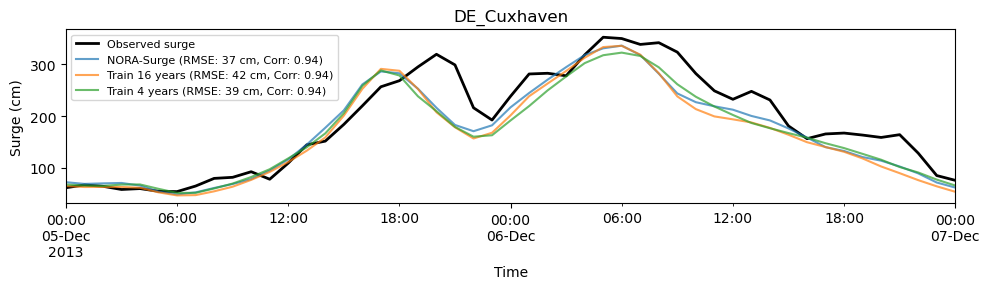

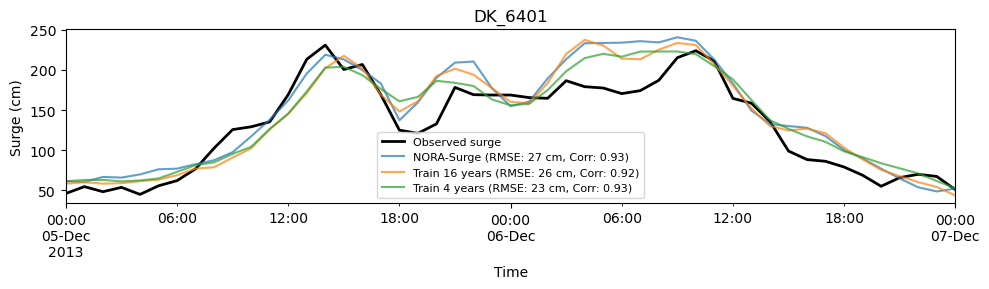

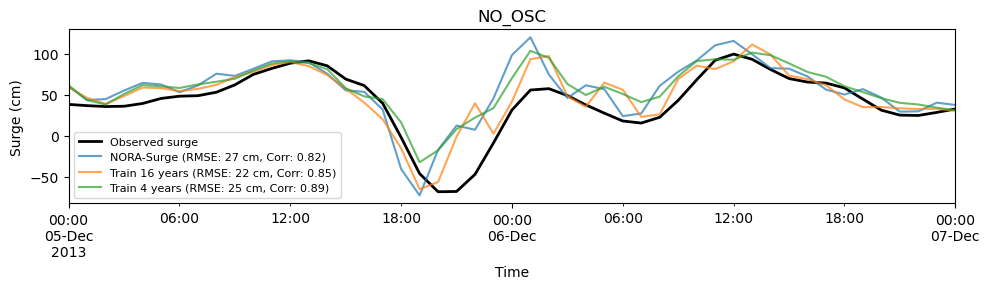

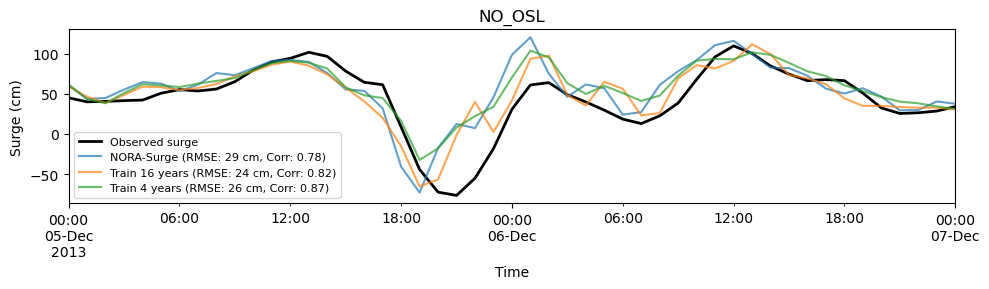

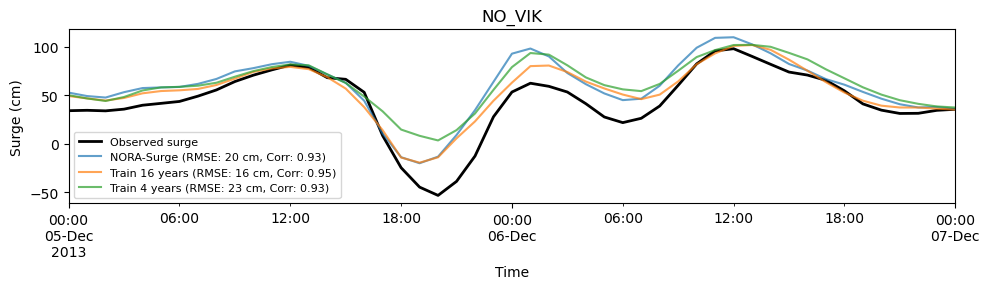

In [43]:
for i in [7, 60, 77, 78, 85]:
    # Remove the mean before plotting
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'observation_surge'] -= np.mean(df_xaver.xs(i, level='station')['observation_surge'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'nora_surge'] -= np.mean(df_xaver.xs(i, level='station')['nora_surge'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'train16yr_uncorr_2010-2018_100k'] -= np.mean(df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'train4yr_uncorr_2010-2018_100k'] -= np.mean(df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'].dropna())
    #
    figsize=(10,3)
    ax = df_xaver.xs(i, level='station').plot(y=['observation_surge'], figsize=figsize, linewidth=2, color='black')
    df_xaver.xs(i, level='station').plot(y=['nora_surge','train16yr_uncorr_2010-2018_100k', 'train4yr_uncorr_2010-2018_100k'], figsize=figsize, alpha=0.7, ax=ax)
    plt.title(df_obs.xs(i, level='station').stationid.values[0])
    # Calulate the stats:
    rmse_16yr = np.sqrt(np.mean((df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_16yr = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                            df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'].dropna())[0,1]
    rmse_4yr = np.sqrt(np.mean((df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_4yr = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                           df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'].dropna())[0,1]
    rmse_nora = np.sqrt(np.mean((df_xaver.xs(i, level='station')['nora_surge'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_nora = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                           df_xaver.xs(i, level='station')['nora_surge'].dropna())[0,1]
    # plt.text(0.05, 0.9, f'NORA Surge RMSE: {rmse_nora:.2f} cm, Corr: {corr_nora:.2f}\n16yr Uncorr RMSE: {rmse_16yr:.2f} cm, Corr: {corr_16yr:.2f}\n4yr Uncorr RMSE: {rmse_4yr:.2f} cm, Corr: {corr_4yr:.2f}', transform=plt.gca().transAxes, 
    #          verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    # Change the names in the legend to include RMSE and Correlation
    new_labels = []
    for label in plt.gca().get_legend().get_texts():
        # print(label.get_text())
        if label.get_text() == 'train16yr_uncorr_2010-2018_100k':
            new_labels.append(f'Train 16 years (RMSE: {rmse_16yr:.0f} cm, Corr: {corr_16yr:.2f})')
        elif label.get_text() == 'train4yr_uncorr_2010-2018_100k':
            new_labels.append(f'Train 4 years (RMSE: {rmse_4yr:.0f} cm, Corr: {corr_4yr:.2f})')
        elif label.get_text() == 'nora_surge':
            new_labels.append(f'NORA-Surge (RMSE: {rmse_nora:.0f} cm, Corr: {corr_nora:.2f})')
        elif label.get_text() == 'observation_surge':
            new_labels.append('Observed surge')
        else:
            new_labels.append(label.get_text())
    plt.gca().legend(new_labels, fontsize=8)
    # plt.legend(fontsize=8)
    plt.xlabel('Time')
    plt.ylabel('Surge (cm)')
    plt.tight_layout()
    plt.show()

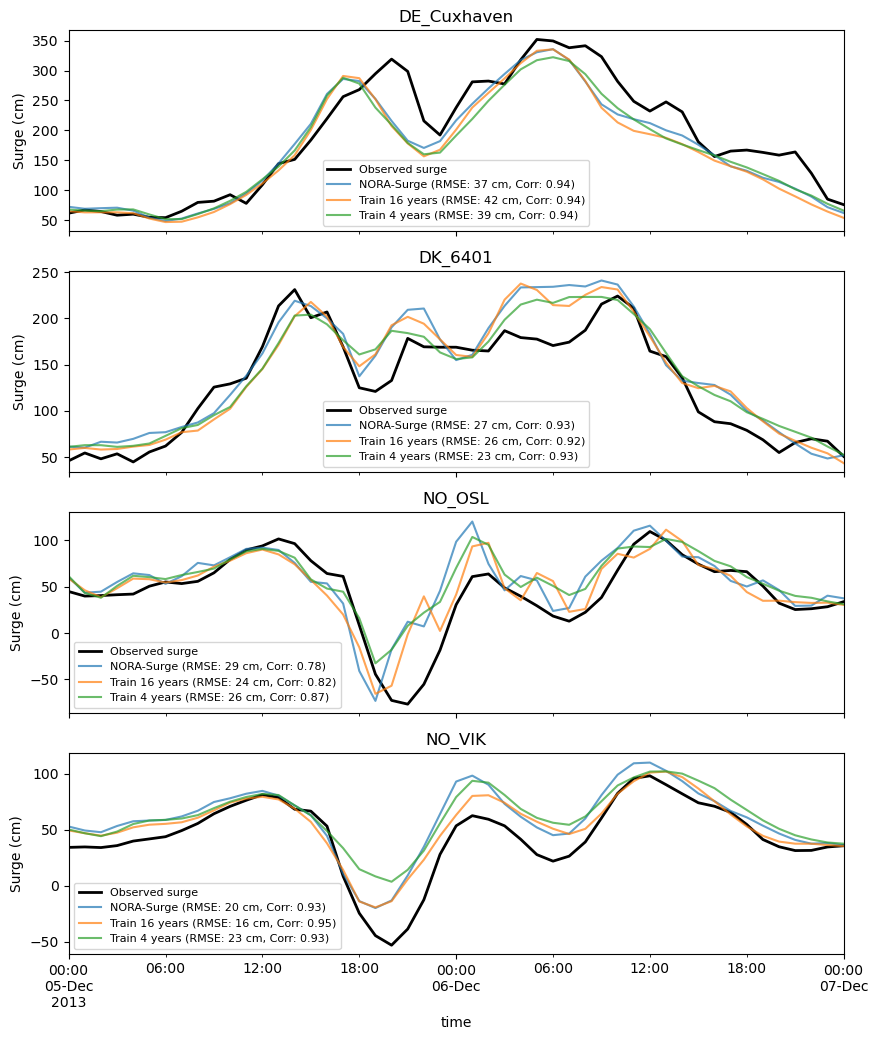

In [51]:
# Do the same as above, but put all stations in one big figure with subplots for each station.
plot_stations = [7, 60, 78, 85]
fig, axes = plt.subplots(len(plot_stations), 1, figsize=(10, 3*len(plot_stations)), sharex=True)
for axi, i in enumerate(plot_stations):
    # Remove the mean before plotting
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'observation_surge'] -= np.mean(df_xaver.xs(i, level='station')['observation_surge'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'nora_surge'] -= np.mean(df_xaver.xs(i, level='station')['nora_surge'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'train16yr_uncorr_2010-2018_100k'] -= np.mean(df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'].dropna())
    # df_xaver.loc[df_xaver.index.get_level_values('station') == i, 'train4yr_uncorr_2010-2018_100k'] -= np.mean(df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'])
    # figsize=(10,3)
    ax = df_xaver.xs(i, level='station').plot(y=['observation_surge'], figsize=(10,3*len(plot_stations)), linewidth=2, color='black', ax=axes[axi])
    df_xaver.xs(i, level='station').plot(y=['nora_surge','train16yr_uncorr_2010-2018_100k', 'train4yr_uncorr_2010-2018_100k'], figsize=(10,3*len(plot_stations)), alpha=0.7, ax=ax)
    ax.set_title(df_obs.xs(i, level='station').stationid.values[0])
    # Calulate the stats:
    rmse_16yr = np.sqrt(np.mean((df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_16yr = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                            df_xaver.xs(i, level='station')['train16yr_uncorr_2010-2018_100k'].dropna())[0,1]
    rmse_4yr = np.sqrt(np.mean((df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_4yr = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                           df_xaver.xs(i, level='station')['train4yr_uncorr_2010-2018_100k'].dropna())[0,1]
    rmse_nora = np.sqrt(np.mean((df_xaver.xs(i, level='station')['nora_surge'] - df_xaver.xs(i, level='station')['observation_surge'])**2))
    corr_nora = np.corrcoef(df_xaver.xs(i, level='station')['observation_surge'].dropna(), 
                           df_xaver.xs(i, level='station')['nora_surge'].dropna())[0,1]
    # Change the names in the legend to include RMSE and Correlation
    # Get the label from axes[axi]
    new_labels = []
    for label in axes[axi].get_legend().get_texts():
        # print(label.get_text())
        if label.get_text() == 'train16yr_uncorr_2010-2018_100k':
            new_labels.append(f'Train 16 years (RMSE: {rmse_16yr:.0f} cm, Corr: {corr_16yr:.2f})')
        elif label.get_text() == 'train4yr_uncorr_2010-2018_100k':
            new_labels.append(f'Train 4 years (RMSE: {rmse_4yr:.0f} cm, Corr: {corr_4yr:.2f})')
        elif label.get_text() == 'nora_surge':
            new_labels.append(f'NORA-Surge (RMSE: {rmse_nora:.0f} cm, Corr: {corr_nora:.2f})')
        elif label.get_text() == 'observation_surge':
            new_labels.append('Observed surge')
        else:
            new_labels.append(label.get_text())
    axes[axi].legend(new_labels, fontsize=8)
    axes[axi].set_ylabel('Surge (cm)')

In [12]:
# all_rmse, all_bias, all_corr
for keyes in df_xaver.columns:
    try:
        print(keyes, np.mean(stats_xaver[0][keyes]), np.mean(stats_xaver[2][keyes]))
    except:
        pass

nora_surge 15.991031 0.9072846520838309
nora_surge_corrected 15.080088781158263 0.9132518225421321
train16yr_uncorr_2010-2018_100k 16.07620167297561 0.9066447125526336
train4yr_uncorr_2010-2018_100k 15.846830603470277 0.9047991839787523


In [ ]:
df_obs

stationid   latitude  longitude  observation  \
station time                                                                   
0       2010-01-01 00:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
        2010-01-01 01:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
        2010-01-01 02:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
        2010-01-01 03:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
        2010-01-01 04:00:00  DE_AlteWeser  53.863300   8.127500          NaN   
...                                   ...        ...        ...          ...   
97      2019-01-01 19:00:00       UK_Wick  58.440971  -3.086306   270.500000   
        2019-01-01 20:00:00       UK_Wick  58.440971  -3.086306   286.100006   
        2019-01-01 21:00:00       UK_Wick  58.440971  -3.086306   269.399994   
        2019-01-01 22:00:00       UK_Wick  58.440971  -3.086306   231.199997   
        2019-01-01 23:00:00       UK_Wick  58.440971  -3.086306   181.899994   

                             pytide_prediction  q_flag  nora_surge  \
station time                                                         
0       2010-01-01 00:00:00         127.228615     0.0  -40.153900   
        2010-01-01 01:00:00          64.462318     0.0  -38.648827   
        2010-01-01 02:00:00          -7.212074     0.0  -37.193420   
        2010-01-01 03:00:00         -66.939262     0.0  -35.668941   
        2010-01-01 04:00:00        -115.728935     0.0  -34.284744   
...                                        ...     ...         ...   
97      2019-01-01 19:00:00         303.047913     1.0  -14.649345   
        2019-01-01 20:00:00         315.238861     1.0  -15.854261   
        2019-01-01 21:00:00         300.459564     1.0  -19.501032   
        2019-01-01 22:00:00         264.531036     1.0  -23.495564   
        2019-01-01 23:00:00         217.547470     1.0  -26.658443   

                             observation_surge  nora_surge_corrected  \
station time                                                           
0       2010-01-01 00:00:00                NaN            -30.783630   
        2010-01-01 01:00:00                NaN            -29.278555   
        2010-01-01 02:00:00                NaN            -27.823151   
        2010-01-01 03:00:00                NaN            -26.298672   
        2010-01-01 04:00:00                NaN            -24.914473   
...                                        ...                   ...   
97      2019-01-01 19:00:00         -32.547913                   NaN   
        2019-01-01 20:00:00         -29.138855                   NaN   
        2019-01-01 21:00:00         -31.059570                   NaN   
        2019-01-01 22:00:00         -33.331039                   NaN   
        2019-01-01 23:00:00         -35.647476                   NaN   

                             train16yr_uncorr_10d_100k  ...  \
station time                                            ...   
0       2010-01-01 00:00:00                        NaN  ...   
        2010-01-01 01:00:00                        NaN  ...   
        2010-01-01 02:00:00                        NaN  ...   
        2010-01-01 03:00:00                        NaN  ...   
        2010-01-01 04:00:00                        NaN  ...   
...                                                ...  ...   
97      2019-01-01 19:00:00                        NaN  ...   
        2019-01-01 20:00:00                        NaN  ...   
        2019-01-01 21:00:00                        NaN  ...   
        2019-01-01 22:00:00                        NaN  ...   
        2019-01-01 23:00:00                        NaN  ...   

                             train5yr_uncorr_10d_100k  \
station time                                            
0       2010-01-01 00:00:00                       NaN   
        2010-01-01 01:00:00                       NaN   
        2010-01-01 02:00:00                       NaN   
        2010-01-01 03:00:00           

In [28]:
# Create a heatmap scatterplot for all data points comparing observation_surge and train16yr_uncorr_2010-2018_100k
# which_exp = 'train16yr_uncorr_2010-2018_100k'
which_exp = 'train5yr_uncorr_2010-2018_100k'
# which_exp = 'nora_surge'
x = df_obs['observation_surge']
y = df_obs[which_exp]
# Remove NaN and inf values
mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
x = x[mask]
y = y[mask]
# Remove the mean from both x and y to focus on surge anomalies
x = x - np.mean(x)
y = y - np.mean(y)


In [22]:
# # All stations
# minval = -300
# maxval = 350
# Norwegian stations only
minval = -100
maxval = 150

In [ ]:
# Create heatmap scatterplot
import seaborn as sns
# Create a 2D histogram (heatmap scatterplot)
plt.figure(figsize=(8,6))
sns.kdeplot(x=x, y=y, fill=True, cmap='viridis', levels=100, thresh=0.05)
plt.plot([minval, maxval], [minval, maxval], 'r--')
plt.xlim([minval, maxval])
plt.ylim([minval, maxval])
plt.xlabel('Observed Surge (cm)')
plt.ylabel(f'Modeled Surge ({which_exp}) (cm)')
plt.title('Heatmap Scatterplot of Observed vs Modeled Surge')
plt.grid(True)
ofile_fig = os.path.join(odir_figs, f'heatmap_scatter_observed_vs_modeled_surge_{which_exp}.png')
plt.savefig(ofile_fig)
plt.show()
plt.close()

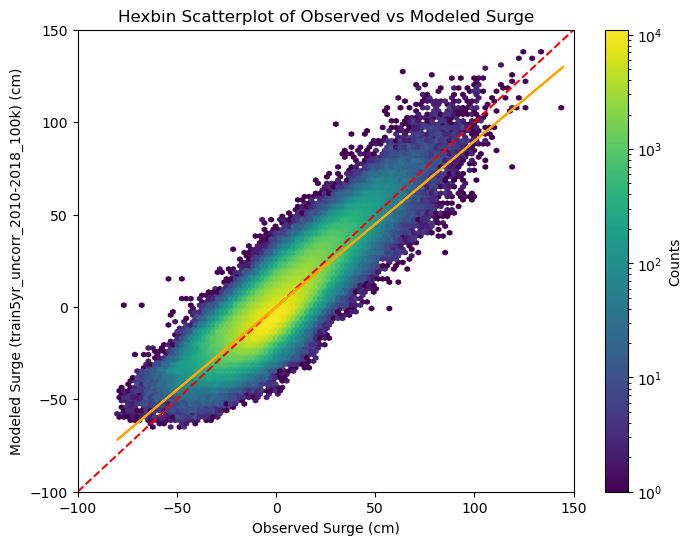

In [30]:
# Do the same as above, but not using seaborn, just matplotlib with hexbin.
# Use log scale for colorbar.
plt.figure(figsize=(8,6))
plt.hexbin(x, y, gridsize=100, cmap='viridis', mincnt=1, bins='log')
plt.plot([minval, maxval], [minval, maxval], 'r--')
# Also add a regression line based on x and y
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='orange', label='Regression line')
# plt.legend()
plt.xlim([minval, maxval])
plt.ylim([minval, maxval])
plt.xlabel('Observed Surge (cm)')
plt.ylabel(f'Modeled Surge ({which_exp}) (cm)')
plt.title('Hexbin Scatterplot of Observed vs Modeled Surge')
plt.colorbar(label='Counts')
ofile_fig = os.path.join(odir_figs, f'hexbin_scatter_observed_vs_modeled_surge_{which_exp}.png')
plt.savefig(ofile_fig)
plt.show()
plt.close()

In [29]:
# Plot the same as above, but only for Norwegian stations.
df_obs_no = df_obs[df_obs.index.get_level_values('station').isin(no_station_sids)]
x = df_obs_no['observation_surge']
y = df_obs_no[which_exp]
# Remove NaN and inf values
mask = ~np.isnan(x) & ~np.isnan(y) & ~np.isinf(x) & ~np.isinf(y)
x = x[mask]
y = y[mask]
# Remove the mean from both x and y to focus on surge anomalies
x = x - np.mean(x)
y = y - np.mean(y)